# Regression Diagnostics in Practice: Fire Damage & Executive Salaries

**Statistics course project — Baruch College, Zicklin School of Business, Fall 2025**
**By Nicholas Osani** *(completed solo; submitted under a group header in the course — all analysis, code, and write-up are my own)*

Two applied studies in linear regression, with the emphasis on *checking* the model rather than just fitting it:
residual diagnostics, multicollinearity (VIF), influence measures, hypothesis tests, and backwards-elimination
model selection — then translating every result back into plain-English, in-context conclusions.

**Tools:** Python (pandas, statsmodels, scipy, matplotlib)


### Group 3: Vashisht Ramsaran, Shahed Ahmed, Stephanie Aucapina, Nicholas Osani, & Brandon Ram.  

# Study 1: Simple Linear Regression



---



First, load the fire data and examine its structure and summary statistics:

In [1]:
import pandas as pd

# Load the fire data
fires = pd.read_csv('data/Fires.csv')
print(fires.info())        # structure and data types
print(fires.head())        # first 5 observations
print(fires.describe())    # summary statistics


<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DISTANCE  15 non-null     float64
 1   DAMAGE    15 non-null     float64
dtypes: float64(2)
memory usage: 372.0 bytes
None
   DISTANCE  DAMAGE
0       3.4    26.2
1       1.8    17.8
2       4.6    31.3
3       2.3    23.1
4       3.1    27.5
        DISTANCE     DAMAGE
count  15.000000  15.000000
mean    3.280000  26.413333
std     1.576252   8.068976
min     0.700000  14.100000
25%     2.200000  20.950000
50%     3.100000  26.100000
75%     4.450000  31.300000
max     6.100000  43.200000


* Dataset contains 15 observations with 2 fields: DISTANCE (distance to nearest fire station, in miles) and DAMAGE (fire damage, in $1000s).
* Both columns are quantitative, have missing values with an average distance of ~3.28 miles and average damage of ~ 26.41 (thousand dollars).
* The standard deviation is from 1.57 miles for distance and 8.07 thousand dollars for damage.
* The range goes from 0.70 to 6.10 in miles of distance and 14.1 to 43.2 thousand dollars in damage.
* IQR is 2.25 miles for distance and 17.2 thousand dollars of damage.

---

          DISTANCE    DAMAGE
DISTANCE  1.000000  0.960978
DAMAGE    0.960978  1.000000


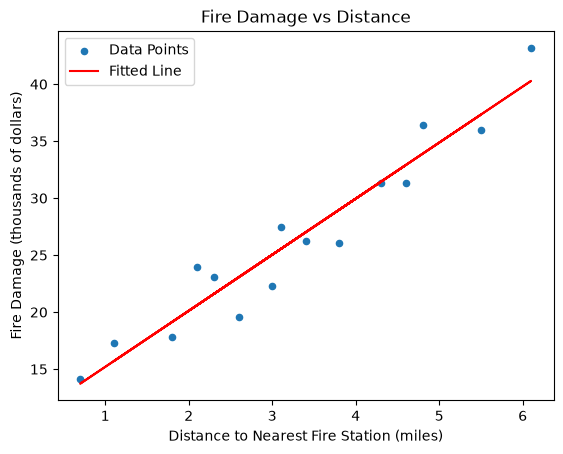

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Compute Pearson correlation
print(fires.corr())

# X = predictor (DISTANCE), y = response (DAMAGE)
X = fires['DISTANCE']
y = fires['DAMAGE']

# Add constant to X for intercept term (this creates a column of 1s for β₀)
X_with_const = sm.add_constant(X)

# Fit the simple linear regression model
model = sm.OLS(y, X_with_const).fit()

# Get the predicted Y values (fitted values) from the model
y_pred = model.predict(X_with_const)

# Create scatterplot using pandas
ax = fires.plot(kind='scatter', x='DISTANCE', y='DAMAGE', label='Data Points')

# Overlay the fitted regression line in red
plt.plot(X, y_pred, color='red', label='Fitted Line')

# Label the plot
plt.title("Fire Damage vs Distance")
plt.xlabel("Distance to Nearest Fire Station (miles)")
plt.ylabel("Fire Damage (thousands of dollars)")
plt.legend()
plt.show()


The correlation between distance and damage is r ≈ 0.961, indicating a very strong positive linear association. The scatterplot (Figure 1) confirms this: as the distance from the fire station increases, fire damage tends to increase markedly.

* Figure 1: Scatterplot of fire damage vs. distance. There is a clear positive linear trend: fires that occur farther from a station tend to result in greater damage. The red line is the fitted least squares regression line (discussed below), showing the upward slope of the relationship

---

We then fit a simple linear regression model predicting fire damage from distance. Using statsmodels, we include an intercept term and estimate the model:

In [3]:
import statsmodels.api as sm

# Define response and predictor
X = sm.add_constant(fires['DISTANCE'])   # adds intercept column
y = fires['DAMAGE']

# Fit the regression model
model1 = sm.OLS(y, X).fit()
print(model1.params)          # coefficients
print(model1.summary())


const       10.277929
DISTANCE     4.919331
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                 DAMAGE   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     156.9
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           1.25e-08
Time:                        18:59:19   Log-Likelihood:                -32.811
No. Observations:                  15   AIC:                             69.62
Df Residuals:                      13   BIC:                             71.04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

Damage=10.28+4.92×Distance,

where “Damage” is in $1000s and “Distance” is in miles. According to this model:

Intercept (10.28): When distance = 0, predicted damage is 10.28 thousand dollars.


> In context, a fire next door to a station would cause about 10k damage on average. Since 0 miles wasn’t observed, its exact value is not that important.



Slope (4.92): For each additional mile of distance, predicted fire damage increases by about 4.92  thousand.

> In other words, a fire 1 mile farther from the station is expected to cause about 4,920 more damage, on average.




Interpretation:


* The slope is highly significant (t = 12.525, p <
0.0001), indicating a statistically significant positive relationship between distance and damage.
* The intercept is also significantly different from zero (p < 0.0001). The model’s R² = 0.923, meaning about 92.3% of the variability in fire damage is explained by distance alone, a very strong explanatory power.

This suggests distance to the fire station is a key factor in fire damage.

---

# We now assess whether the linear regression assumptions are reasonably met:


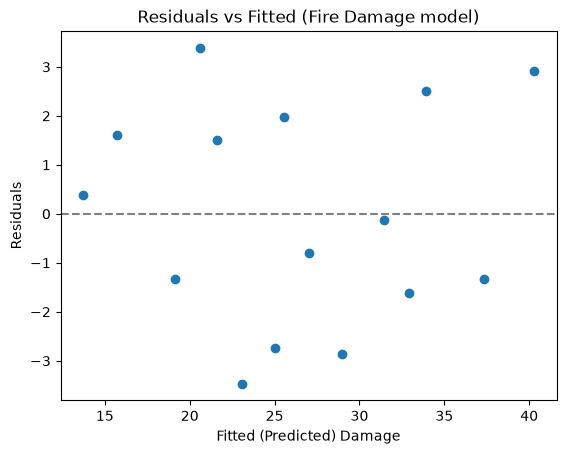

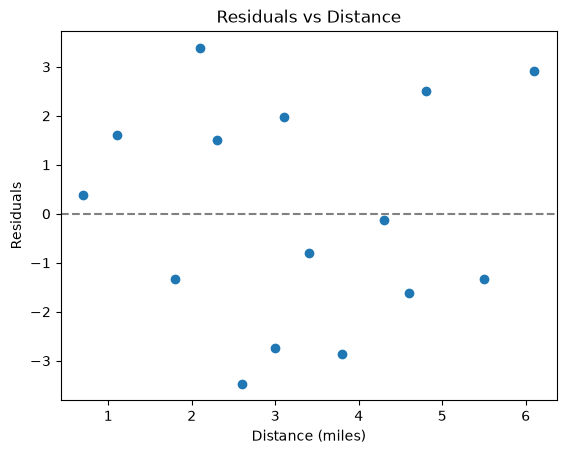

In [4]:
# Calculate residuals and fitted values
residuals = model1.resid
fitted = model1.fittedvalues

# Residuals vs Fitted plot
plt.scatter(fitted, residuals)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Fitted (Predicted) Damage")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Fire Damage model)")
plt.show()

# Residuals vs Predictor (Distance)
plt.scatter(fires['DISTANCE'], residuals)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Distance (miles)")
plt.ylabel("Residuals")
plt.title("Residuals vs Distance")
plt.show()


Linearity & Equal Variance:

We plot residuals vs. fitted values and residuals vs. the predictor to check if residuals have no systematic pattern and constant variance.



*   Figure 2: Residuals vs. fitted values for the fire damage model. The residuals are randomly scattered around zero with no obvious trend or funnel shape. This suggests the linear form is appropriate and the variance of residuals is roughly constant (homoscedasticity).

*   Figure 3: Residuals vs. distance (predictor). This shows essentially the same pattern as residuals vs fitted (since there is only one predictor). There is no clear curvature, reinforcing that a straight-line model is adequate. Residual spread is roughly similar across distances, indicating constant variance.


Both plots show no strong pattern – residuals hover around zero across all fitted values and distances. There may be a slight increase in residual magnitude at the extreme distances (e.g., a moderately large residual at the largest distance ~6 miles), but overall there is no clear violation of homoscedasticity or linearity.

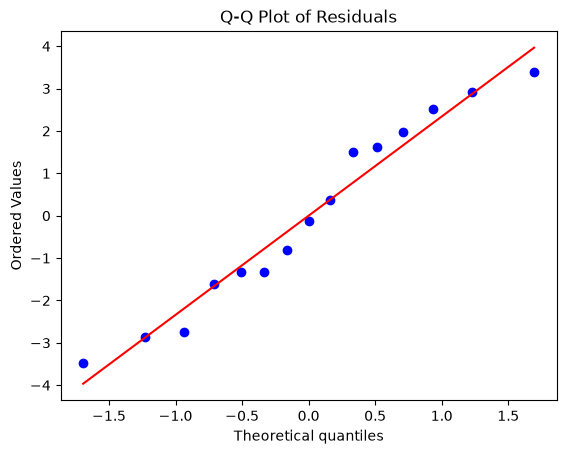

In [5]:
import scipy.stats as stats
# Q-Q plot of residuals
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


Normality of Residuals:
> We use a Q-Q plot to check if residuals follow a normal distribution


*   Figure 4: Normal Q-Q plot of residuals. The residual points lie reasonably close to the diagonal line. Aside from very small deviations at the ends, the residuals appear approximately normally distributed.


With only 15 observations, some deviation is expected, but the Q-Q plot is roughly linear. The normality assumption looks acceptable.


In [6]:
import numpy as np

influence = model1.get_influence()
std_resid = influence.resid_studentized_internal  # standardized residuals
cooks_d = influence.cooks_distance[0]

print("Max |Standardized Residual|:", np.max(np.abs(std_resid)))
print("Max Cook's distance:", np.max(cooks_d))

Max |Standardized Residual|: 1.5609748185316128
Max Cook's distance: 0.4705581511860761


The largest absolute standardized residual is about 1.56, thus within ±3. No residual exceeds 2, so we have no extreme outlier in terms of Y.

For influence:


*   The largest Cook’s distance is ~0.47. Given the fact that when Cook’s D > 1 or > 4/n is a potential concerns and here, 4/n ≈ 0.27, we have to look closer.
*   one point (observation #13) has Cook’s D ≈ 0.47, above 0.27.


Thus we plot Cook’s distances to see this in context:

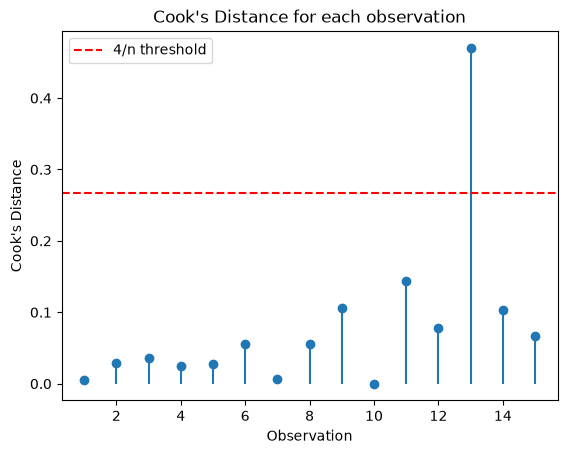

In [7]:
# Plot Cook's distance for each point
plt.stem(range(1, len(cooks_d)+1), cooks_d, basefmt=" ")
plt.axhline(4/len(cooks_d), color='red', linestyle='--', label="4/n threshold")
plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for each observation")
plt.legend()
plt.show()


Figure 5: Cook’s distance values for all 15 fires.
> Most points have very low influence.  However, observation 13 has the highest Cook’s D ≈ 0.47, exceeding the 4/n ≈ 0.27 threshold (dashed line), meaning it has moderate influence on the regression fit. However, 0.47 is still below 1, indicating it’s not too excessive.



Observation 13 is a fire that occurred 6.1 miles from a station with $43.2k damage, the farthest distance and one of the highest damages. So, it makes sense that it influences the slope noticeably, but not enough to invalidate the model. We will keep it, as there are no compelling reasons (e.g. data error) to remove it.

***Assumption Conclusion***

All regression assumptions appear reasonably satisfied. The linear model seems appropriate and the fit is not too affected by any single observation.

---


# Significance Tests:

The model summary from the beginning provides t-tests for both the intercept and slope.

* For the slope, the null hypothesis H0: slope = 0 was easily rejected (t = 12.53, p ≈ 1.25e-08). This confirms distance is a significant predictor of fire damage.

* The intercept’s test (H₀: intercept = 0) is also significant (p < 0.001)

We now perform further statistical inference and make predictions using the model:



In [8]:
distance_val = 3
model1.conf_int()
# Manually create the DataFrame for prediction
new_X = pd.DataFrame({'const': 1.0, 'DISTANCE': [distance_val]})
pred = model1.get_prediction(new_X).summary_frame(alpha=0.05)
print("Predicted mean damage (in thousands of dollars):", pred['mean'][0])
print("95% CI for mean:", pred['mean_ci_lower'][0], "to", pred['mean_ci_upper'][0])
print("95% PI for individual:", pred['obs_ci_lower'][0], "to", pred['obs_ci_upper'][0])

Predicted mean damage (in thousands of dollars): 25.03592072983748
95% CI for mean: 23.72219173608568 to 26.349649723589277
95% PI for individual: 19.862187250476065 to 30.20965420919889


**95% Confidence Interval for Slope**
From the model summary:

    DISTANCE       4.9193      0.393     12.525      0.000       4.071       5.768

 the 95% CI for the slope (Distance coefficient) is [4.07, 5.77]. We are 95% confident that each mile of extra distance increases expected damage by between 4.07k and 5.77k, on average.



>   Prediction Example: Suppose we want to predict fire damage for a fire that occurs 3 miles from the nearest station. We can obtain mean (expected) damage at 3 miles: using the regression equation, y^=10.28+4.92∗(3)≈25.04 (in 1000s).








**95% CI for the mean damage at 3 miles:**

We use model1.get_prediction to get an interval: approximately [23.72k, 6.35k].



>  This means if we considered all fires 3 miles away, we’re 95% confident their average damage lies in that range.

**95% Prediction Interval for an individual fire at 3 miles:**

≈[19.86k, 30.21k].

> Thus, we are 95% confident a single fire 3 miles out would have damage in this interval. (Note: The prediction interval is much wider than the confidence interval for the average, accounting for individual variations).

Therefore, at 3 miles, we’d predict about 25k damage; the true mean damage is likely within 23.7–26.3k (95% confidence), and an individual fire’s damage would typically range from about 19.9k to 30.2k (95% prediction interval).






# Summary of Findings (Study 1)

In this simple linear regression analysis, distance to the nearest fire station was found to be a strong, significant predictor of fire damage.
* For every 1 mile increase in distance, fire damage is expected to increase by roughly $4,920 on average.
* The model explains about 92% of the variation in damages, indicating an excellent fit.
* Diagnostic checks showed the assumptions of linear regression were reasonably met: residuals displayed no clear patterns (supporting linearity and constant variance) and were approximately normal, with no alarming outliers or overly influential points.

In conclusion, the farther a property is from a fire station, the greater the damage incurred in the event of a fire – showing the importance of fire station proximity in mitigating damage.

---

---

# Study 2: Multiple linear regression

First, load the dataset and inspect its structure:

In [9]:
import pandas as pd
import statsmodels.formula.api as smf

salaries = pd.read_csv('data/Salaries.csv')
# Drop ID and fit full model with all X1...X10
sal_df = salaries.drop(columns=['ID'])
full_model = smf.ols('Y ~ X1 + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + X10', data=sal_df).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     106.5
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           4.41e-45
Time:                        18:59:19   Log-Likelihood:                 121.52
No. Observations:                 100   AIC:                            -221.0
Df Residuals:                      89   BIC:                            -192.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.0219      0.148     67.692      0.0

**Key results from the full model:**

* R² = 0.923 (Adj. R² = 0.914): The ten predictors together explain about 92.3% of the variance in log-salaries, which is very high. The F-test for overall model is highly significant (p ~ 4.4e-45), indicating the model is useful.

* Significant predictors: From the coefficient table, X1 (Experience), X2 (Education), X3 (Bonus eligibility), X4 (# supervised), and X5 (Assets) all have p-values < 0.001. These are statistically significant at the 5% (and even 0.1%) level.

* Non-significant predictors: X6 (Board member), X7 (Age), X8 (Profits), X9 (International), X10 (Sales) have high p-values (0.19 to 0.74), suggesting they do not contribute significantly when the other variables are in the model.

**Interpretation of significant coefficients:**

* Intercept = 10.0219: When all X’s are 0 (which might be outside plausible ranges for some variables), the expected log-salary is ~10.02. This is a baseline (roughly corresponding to a salary of e^10.02 ≈ $22,500) for an executive with zero experience, zero education, etc., which is not realistic, so we won’t interpret it literally

* X1 (Experience): coef ~ 0.0279. Each additional year of experience is associated with an increase in log-salary by 0.0279.

* X2 (Education): coef ~ 0.0290. Each additional year of education corresponds to a ~3.0% increase in salary.

* X3 (Bonus eligible = 1 vs 0): coef ~ 0.2243. Bonus eligibility is associated with a higher log-salary by 0.2243, i.e., being bonus-eligible corresponds to an expected salary about 25% higher than a non-eligible employee.

* X4 (Supervised): coef ~ 0.0005 per employee. For each additional person supervised, log-salary increases by 0.0005. While very small per person, if an executive manages, 100 more employees, that’s a 5% higher salary.

* X5 (Corporate Assets \$M): coef ~ 0.0020 per 1M\$. Every extra 1 million in assets under management is associated with a 0.0020 increase in log-salary, or 0.20% higher salary per $1M.

**Interpretation of non-significant coefficients:**

* X6 (Board member): coef ~ -0.015 (p = 0.364). This suggests being a board member is not significantly affecting salary once other factors are accounted for.

* X7 (Age): coef ~ -0.0005 (p = 0.724). Age by itself doesn’t have a significant unique effect on log-salary once experience (which is correlated with age) is included.

* X8 (Profits): coef ~ -0.0026 (p = 0.609). The company’s profit level doesn’t show a significant linear relationship with the executive’s salary in the presence of other variables.

* X9 (International responsibilities): coef ~ -0.0266 (p = 0.196). Having international duties showed a slight negative coefficient but not statistically significant.

* X10 (Sales): coef ~ -0.0010 (p = 0.742). Total sales isn’t contributing significantly given the other predictors.

In summary, the model explains a very high amount of the salary variation (R-squared = 0.923) and is statistically significant (tiny p-value for the F-statistic).

Key Predictors: X1 (Experience), X2 (Education), X3 (Bonus eligibility), X4 (# supervised), and X5 (Assets) are all highly significant predictors of salary.

Less Important Predictors: X6 (Board member), X7 (Age), X8 (Profits), X9 (International), and X10 (Sales) were not found to be statistically significant in this model.

However: The model summary also indicates a potential issue with multicollinearity

---

# Before refining the model, we check regression assumptions for the full model:



**1. Multicollinearity:**

With many predictors, we examine correlations and Variance Inflation Factors (VIF) to detect multicollinearity.

In [10]:
# Correlation matrix of predictors
print(sal_df.drop(columns=['Y']).corr())
# Calculate VIF for each predictor
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = sm.add_constant(sal_df.drop(columns=['Y']))
for i, col in enumerate(X.columns[1:], start=1):
    print(col, "VIF:", variance_inflation_factor(X.values, i))


           X1        X2        X3        X4        X5        X6        X7  \
X1   1.000000  0.000501  0.045423 -0.010210  0.004393  0.041291  0.771514   
X2   0.000501  1.000000  0.043078 -0.179306  0.045454 -0.060883 -0.063603   
X3   0.045423  0.043078  1.000000 -0.212775  0.087308  0.112328  0.097185   
X4  -0.010210 -0.179306 -0.212775  1.000000  0.107648 -0.217057  0.042032   
X5   0.004393  0.045454  0.087308  0.107648  1.000000 -0.143413 -0.032402   
X6   0.041291 -0.060883  0.112328 -0.217057 -0.143413  1.000000 -0.131093   
X7   0.771514 -0.063603  0.097185  0.042032 -0.032402 -0.131093  1.000000   
X8   0.006552  0.060923  0.038234  0.000506  0.182711 -0.185035  0.026655   
X9   0.037623  0.064012 -0.048354 -0.001846  0.149762  0.009372 -0.040712   
X10  0.168279  0.034111 -0.168550 -0.035004  0.039865 -0.063580  0.002144   

           X8        X9       X10  
X1   0.006552  0.037623  0.168279  
X2   0.060923  0.064012  0.034111  
X3   0.038234 -0.048354 -0.168550  
X4   0.0

* The correlation matrix shows most predictors have low correlations with each other (generally < 0.2), except Experience (X1) and Age (X7) which have a high correlation (~0.77).

* This makes sense as older executives tend to have more experience.

* The VIFs for X1 and X7 come out around ~2.9 each, while all other variables have VIF near 1.1 or less. A VIF of 2.9 is not extremely high, but it does indicate some multicollinearity between experience and age. This may be why age (X7) was not significant, as its effect overlaps with experience.

* Other predictors show no concerning multicollinearity.

* Apart from X1 & X7, no other strong multicollinearity is present

**2. Assessing Linearity and Equal Variance: Residuals vs. Fitted Plot:**

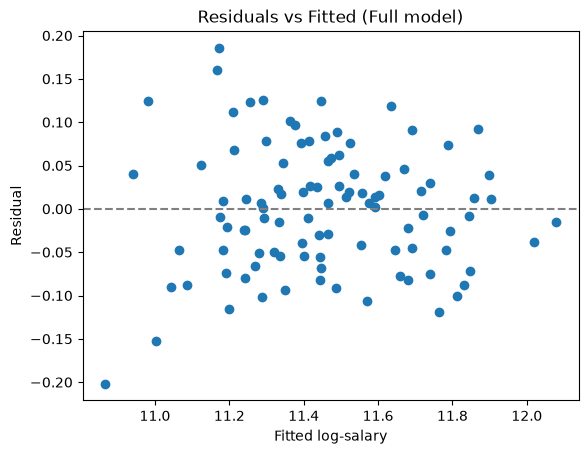

In [11]:
residuals_full = full_model.resid
fitted_full = full_model.fittedvalues
plt.scatter(fitted_full, residuals_full)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Fitted log-salary")
plt.ylabel("Residual")
plt.title("Residuals vs Fitted (Full model)")
plt.show()

Figure 1: The residuals vs fitted for the full model showed a roughly random scatter. There was no obvious curvature, and the spread of residuals looked fairly constant across the range of fitted values .

This suggests the linear form is appropriate and error variance is constant.

**3. Assessing Normality of Residuals: Q-Q Plot:**

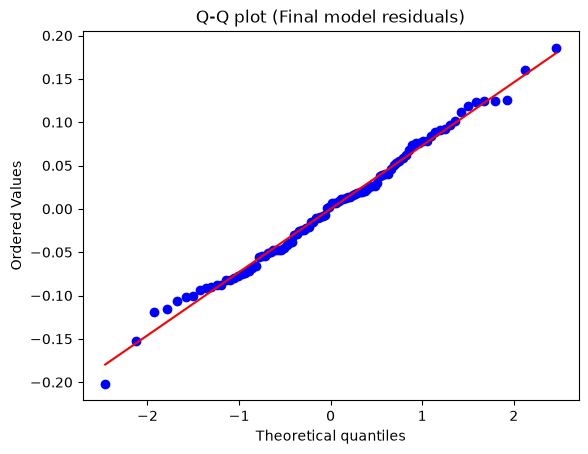

In [12]:
stats.probplot(residuals_full, dist="norm", plot=plt)
plt.title("Q-Q plot (Final model residuals)")
plt.show()

The Q-Q plot for full model residuals was essentially linear with no major outliers, indicating the residuals are approximately normally distributed.

**3. Outliers & Influence:**

In [13]:
import numpy as np

influence2 = full_model.get_influence()
std_resid = influence2.resid_studentized_internal  # standardized residuals
cooks_d = influence2.cooks_distance[0]

print("Max |Standardized Residual|:", np.max(np.abs(std_resid)))
print("Max Cook's distance:", np.max(cooks_d))

Max |Standardized Residual|: 2.854987371458645
Max Cook's distance: 0.11781627017115269


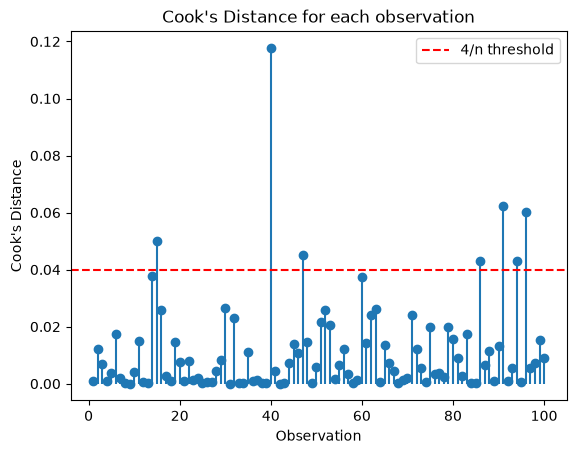

In [14]:
# Plot Cook's distance for each point
plt.stem(range(1, len(cooks_d)+1), cooks_d, basefmt=" ")
plt.axhline(4/len(cooks_d), color='red', linestyle='--', label="4/n threshold")
plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for each observation")
plt.legend()
plt.show()

We compute standardized residuals and Cook’s distances for the full model.
* No residual in the full model exceeded ±3; the largest standardized residual was about 2.85.
* Figure 2: A few observations had Cook’s distance above the 4/n (~0.04) threshold, with the maximum Cook’s D ~0.12 for one case (well below 1).

This suggests no single data point is too influential on the overall fit.

---

# **Simplifying the Model:**

Since several predictors have high p-values, we use backwards elimination to simplify the model. We iteratively remove the predictor with the highest p-value (above 0.05) and refit until all remaining predictors are significant:

1.  X10 (Total sales) has p = 0.742 (highest). Remove X10.

2.  Refit without X10. Now X7 (Age) has p ≈ 0.768 (highest). Remove X7.

3.  Refit without X10, X7. Next highest p is X8 (Profits) at ~0.612. Remove X8.

4.  Refit without X10, X7, X8. Next, X6 (Board) has p ~0.44. Remove X6.

5.  Refit without X10, X7, X8, X6. Now X9 (International) p ~0.20. Remove X9.

Stop: All remaining predictors have p < 0.05.


The final model includes X1, X2, X3, X4, X5. We check the final model summary:

In [15]:
final_model = smf.ols('Y ~ X1 + X2 + X3 + X4 + X5', data=sal_df).fit()
print(final_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     218.1
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           4.30e-50
Time:                        18:59:20   Log-Likelihood:                 120.07
No. Observations:                 100   AIC:                            -228.1
Df Residuals:                      94   BIC:                            -212.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.9619      0.101     98.578      0.0

* All five predictors in this model are highly significant (p-values ~0.000).

* Adj. R² improved slightly, thus indicating the removed variables (X6, X7, X8, X9, X10) contributed little to predicting salary beyond the five retained variables.



# **Final model:**

The coefficients in the final model are very similar to those in the full model for X1–X5, with small changes due to removal of others. Their meanings remain the same


By dropping the other variables, we found that experience, education, bonus eligibility, size of team, and company size (assets) fully capture the predictable variation in salaries in this dataset. Age was redundant with experience and board membership, profits, international duties, and sales did not show measurable impacts on pay after accounting for the key factors.

# **We double-check assumptions on the final model:**

**1. Assessing Linearity and Equal Variance: Residuals vs. Fitted Plot:**

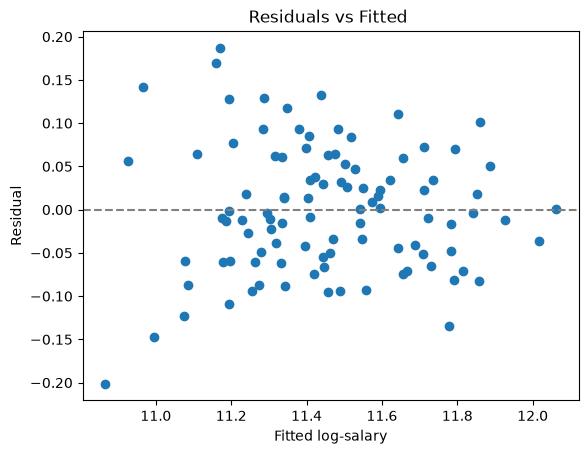

In [16]:
residuals_final = final_model.resid
fitted_final = final_model.fittedvalues
plt.scatter(fitted_final, residuals_final)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Fitted log-salary")
plt.ylabel("Residual")
plt.title("Residuals vs Fitted ")
plt.show()

Figure 3: Residuals vs. fitted values for the final salary model (with X1, X2, X3, X4, X5). The residuals appear randomly scattered around zero, with no discernible pattern or trend. This indicates the linear model is appropriate; there is no evidence of non-linearity or heteroscedasticity (no obvious change in residual spread as fitted values increase).

**2. Assessing Normality of Residuals: Q-Q Plot:**

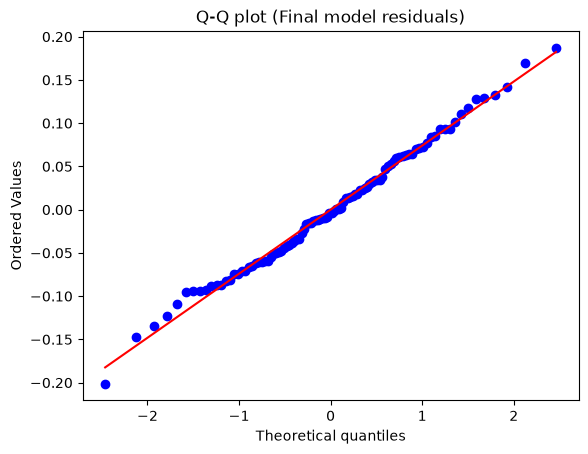

In [17]:
stats.probplot(residuals_final, dist="norm", plot=plt)
plt.title("Q-Q plot (Final model residuals)")
plt.show()

Figure 4: Normal Q-Q plot for residuals of the final model. The points lie very close to the straight line, suggesting that residuals are normally distributed. There are no extreme outliers; the largest deviations at the tails are minor. This supports the normality assumption.

**3. Outliers & Influence:**

Max |Standardized Residual|: 2.820963214588905
Max Cook's distance: 0.144602818097269


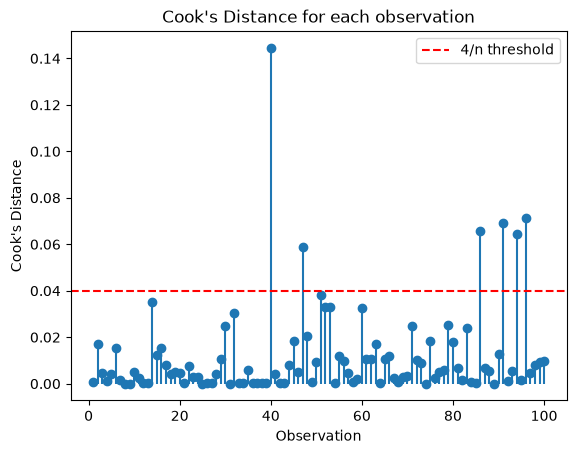

In [18]:
import numpy as np

influence3 = final_model.get_influence()
std_resid = influence3.resid_studentized_internal  # standardized residuals
cooks_d = influence3.cooks_distance[0]

print("Max |Standardized Residual|:", np.max(np.abs(std_resid)))
print("Max Cook's distance:", np.max(cooks_d))

# Plot Cook's distance for each point
plt.stem(range(1, len(cooks_d)+1), cooks_d, basefmt=" ")
plt.axhline(4/len(cooks_d), color='red', linestyle='--', label="4/n threshold")
plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for each observation")
plt.legend()
plt.show()

Figure 5: Again the largest standardized residual is about -2.82 (same case as before, the executive supervising 340 people with low salary) and the next is +2.56; none exceed ±3. A handful of cases have Cook’s distance above 0.04 (4/100), with the maximum ~0.14 for that same outlier case, not enough to unduly influence the model. Therefore, the final model meets all assumptions reasonably well.

---


# **Example Prediction and Final Summary**

Using the final model, we can make predictions.For instance, suppose we have a new executive with the following profile:

10 years of experience (X1 = 10)

16 years of education (X2 = 16)

Bonus eligible (X3 = 1)

Supervises 250 employees (X4 = 250)

$180 million in corporate assets under management (X5 = 180)

We plug these into the model to predict their salary:

In [19]:
new_data = pd.DataFrame({'X1':[10], 'X2':[16], 'X3':[1], 'X4':[250], 'X5':[180]})
pred_log_salary = final_model.predict(new_data)
print("Predicted log-salary:", pred_log_salary[0])
print("Predicted actual salary: $", np.exp(pred_log_salary[0]))


Predicted log-salary: 11.409185927188839
Predicted actual salary: $ 90146.00631341107


This yields a predicted log-salary of ~11.409. Converting from log, that corresponds to an actual salary of about $90,150 per year.



**Summary of Findings**

* In the multiple regression analysis of executive salaries, we identified five
key factors that significantly influence an executive’s pay (in terms of log salary):
  1. Experience: Each additional year of experience is associated with ~2.8% higher salary.

  2. Education: Each additional year of education is associated with ~3.0% higher salary.

  3. Bonus Eligibility: Executives eligible for bonuses earn about 25% more than those who are not, all else equal.

  4. Number of Employees Supervised: Managing more people correlates with higher pay (about 0.05% increase per additional subordinate, which accumulates for large teams).

  5. Corporate Assets: Working in a larger company (or division) with more assets under management also raises salary (~0.2% per $1M in assets).

  These factors together explain roughly 92% of the variance in log-salaries among the 100 executives, a very high explanatory power.

  Other examined factors: being a board member, age, company profits, international responsibilities, and total sales, did not show a significant independent effect on pay after accounting for the above five variables. Those factors either overlap with the key predictors (e.g., age overlaps with experience) or do not strongly influence salary in this dataset.

* All regression assumptions were checked and found to be reasonably satisfied. The residuals showed no major deviations from linearity or constant variance, and they were approximately normally distributed. We detected a couple of mild outliers (notably a young executive with unusually many subordinates for a low salary), but no data point had extreme influence on the model’s estimates. Multicollinearity was low except for a moderate correlation between age and experience, which we resolved by removing age (X7) from the model.

* Additionally, the model can be used for decision-making or prediction: for instance, to estimate fair salary ranges for executives given their experience, education, and responsibilities.

Interpretation: In practical terms, the model suggests that executive compensation is mainly determined by their human capital (experience and education), their eligibility for performance bonuses, and the scope of their responsibilities (team size and company size/assets). Being in a role that includes bonus eligibility or managing more resources (people/assets) also commands higher pay.


